In [27]:
from typing import Annotated, Sequence, TypedDict
from dotenv import load_dotenv
from langchain_core.messages import BaseMessage, ToolMessage, SystemMessage
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode


load_dotenv()


class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]


@tool
def add(a: int, b:int):
    """This function adds two numbers"""

    return a + b

@tool
def subtract(a: int, b: int):
    """This function subtracts two numbers"""

    return a - b

tools = [add, subtract]

llm_name = "llama-3.3-70b-versatile"
llm = ChatGroq(model=llm_name).bind_tools(tools)


def llm_call(state: AgentState) -> AgentState:

    system_prompt = SystemMessage(content="You are my AI assistant, Please answer my query to the best of your ability")

    response = llm.invoke([system_prompt] + state["messages"])

    return {"messages": [response]}

def should_continue(state: AgentState):

    messages = state["messages"]
    last_message = messages[-1]

    if last_message.tool_calls:

        return "continue"
    else:

        return "end"
    


## Create graph

graph = StateGraph(AgentState)
tool_node = ToolNode(tools=tools)

graph.add_node("llm_call", llm_call)
graph.add_node("tool_node", tool_node)


graph.add_edge(START, "llm_call")
graph.add_conditional_edges(
    "llm_call",
    should_continue,

    {
        "continue": "tool_node",
        "end": END
    }
)

graph.add_edge("tool_node", "llm_call")


app = graph.compile()

In [28]:
stream = app.stream(AgentState(messages=["1 + 1"]), stream_mode="values")
stream_list = list(stream)


In [58]:
for s in reversed(stream_list):

    print(s['messages'][-1])
    print(isinstance(s['messages'][-1], ToolMessage))
    # print(s['messages'][-1].tool_calls)

    # if s['messages'][-1].tool_calls:

    #     print(s['messages'][-1].tool_calls)

content='The answer to 1 + 1 is 2.' additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 322, 'total_tokens': 335, 'completion_time': 0.04524895, 'completion_tokens_details': None, 'prompt_time': 0.016644991, 'prompt_tokens_details': None, 'queue_time': 0.013250772, 'total_time': 0.061893941}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019e17bb-9a7d-7720-983f-866544291a4a-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 322, 'output_tokens': 13, 'total_tokens': 335}
False
content='2' name='add' id='f2eb035d-bcb0-4e6e-a359-889d00da9852' tool_call_id='chsy56vcx'
True
content='' additional_kwargs={'tool_calls': [{'id': 'chsy56vcx', 'function': {'arguments': '{"a":1,"b":1}', 'name': 'add'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_

In [ ]:

for s in stream_list:

    # print(s)

    message = s['messages'][-1]

    if isinstance(message, tuple):

        print(message)
    else:

        message.pretty_print()

NameError: name 'stream_list' is not defined

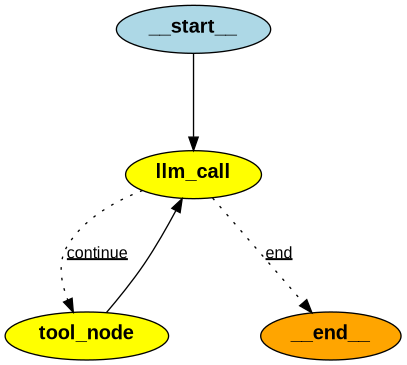

In [ ]:
from IPython.display import display, Image

display(Image(app.get_graph().draw_png()))